# `LeaveCellOut`

`LeaveCellOut` implements spatial block cross-validation using a discrete
global grid system (DGGS). Each fold holds out one grid cell as the test set;
the training set is all observations in every other cell.

This is the leave-one-block-out analogue of `CellStratifiedKFold`, which
distributes each cell's observations across all folds instead of holding them
out whole. Use `LeaveCellOut` when you want to evaluate how well a model
generalises to an entirely unseen geographic region.

In [1]:
import colormaps
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spml.validation import LeaveCellOut

/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = '/Users/ljwolf/Dropbox/work/projects/spquadtree/code/kc_house_data.csv'

df = pd.read_csv(DATA_PATH)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['long'], df['lat']),
    crs='EPSG:4326',
)
print(f'{len(gdf):,} house sales, '
      f'lat {gdf.geometry.y.min():.3f}-{gdf.geometry.y.max():.3f}, '
      f'lon {gdf.geometry.x.min():.3f}-{gdf.geometry.x.max():.3f}')

21,613 house sales, lat 47.156-47.778, lon -122.519--121.315


## H3 grid

H3 resolution 4 yields 7 occupied cells over King County. Increase
the resolution for finer-grained blocks (resolution 5 gives ~26 cells
over this dataset). Use `min_test_size` to exclude cells with very few
observations from serving as test folds.

In [3]:
cv = LeaveCellOut(grid='h3', resolution=4)
splits = list(cv.split(gdf))
print('Resolution :', cv.resolution_)
print('Test folds :', cv.n_cells_, '(one per occupied cell)')

Resolution : 4
Test folds : 7 (one per occupied cell)


/Users/ljwolf/Dropbox/work/dev/geovalidate/src/geovalidate/cv/_cell_stratified_kfold.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts = geom.centroid


### Cell assignments

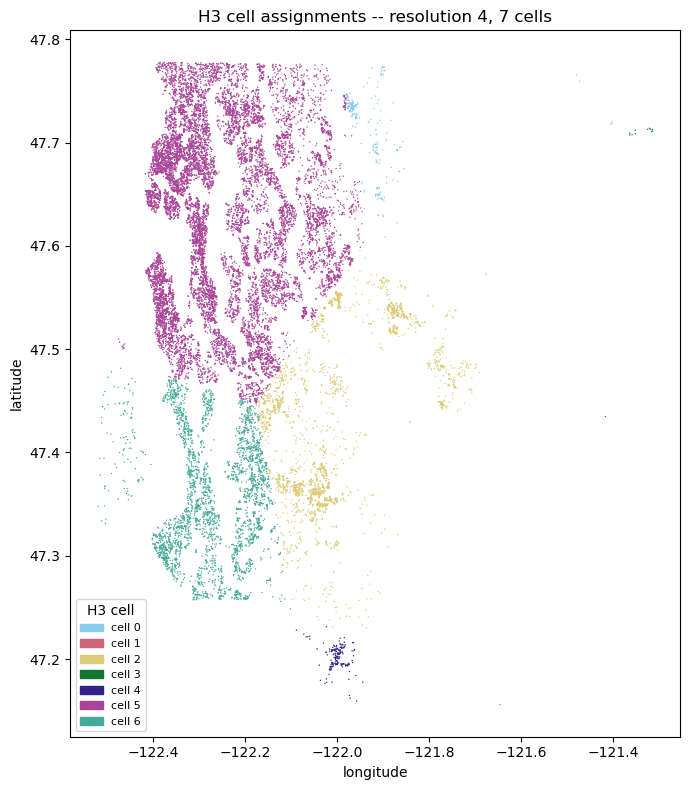

In [4]:
fig, ax = plt.subplots(figsize=(7, 8))
unique_cells, cell_int = np.unique(cv.cell_ids_, return_inverse=True)
sc = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=cell_int, cmap=colormaps.safe[:len(unique_cells)], s=1, linewidths=0,
)
handles = [
    mpatches.Patch(color=sc.cmap(sc.norm(i)), label='cell ' + str(i))
    for i in range(len(unique_cells))
]
ax.legend(handles=handles, loc='lower left', fontsize=8, title='H3 cell')
ax.set_title('H3 cell assignments -- resolution ' + str(cv.resolution_) + ', ' + str(cv.n_cells_) + ' cells')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
plt.show()

### Fold sizes

In [5]:
pd.DataFrame(
    [{'fold': i, 'test size': len(te), 'train size': len(tr)}
     for i, (tr, te) in enumerate(splits)]
)

,fold,test size,train size
0,0,251,21362
1,1,1,21612
2,2,2576,19037
3,3,12,21601
4,4,189,21424
5,5,15223,6390
6,6,3361,18252


### All folds

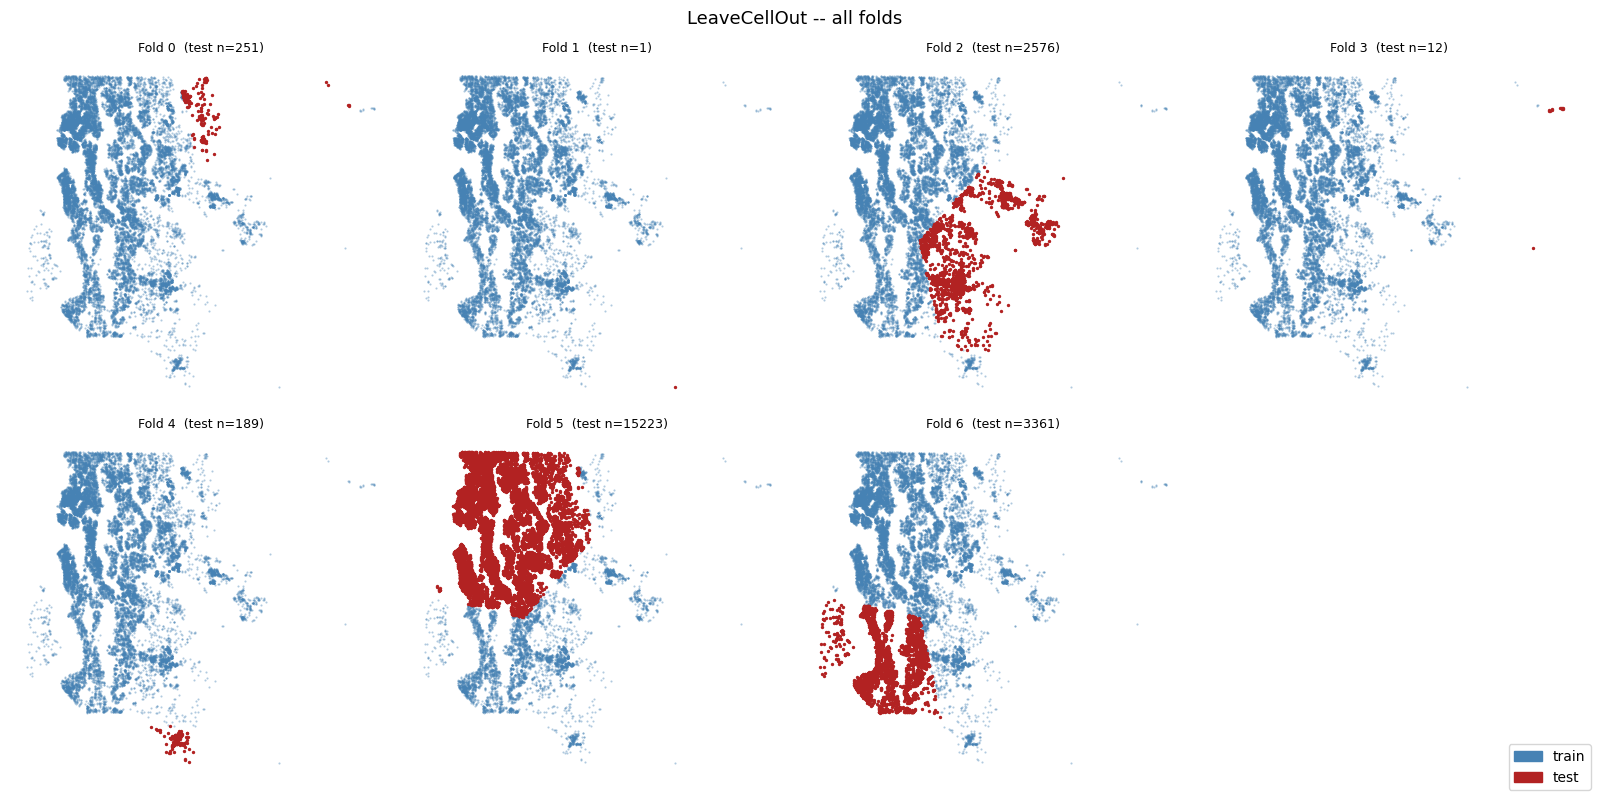

In [6]:
ncols = 4
nrows = int(np.ceil(cv.n_cells_ / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flat

for i, (train, test) in enumerate(splits):
    ax = axes[i]
    ax.scatter(
        gdf.geometry.x.iloc[train], gdf.geometry.y.iloc[train],
        color='steelblue', s=0.3, alpha=0.4,
    )
    ax.scatter(
        gdf.geometry.x.iloc[test], gdf.geometry.y.iloc[test],
        color='firebrick', s=2,
    )
    ax.set_title('Fold ' + str(i) + '  (test n=' + str(len(test)) + ')', fontsize=9)
    ax.set_axis_off()

for ax in list(axes)[cv.n_cells_:]:
    ax.set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color='steelblue', label='train'),
        mpatches.Patch(color='firebrick', label='test'),
    ],
    loc='lower right', fontsize=10,
)
fig.suptitle('LeaveCellOut -- all folds', fontsize=13)
plt.tight_layout()
plt.show()

## A5 grid

The A5 (Icosahedral Snyder Equal Area) grid partitions the globe into equal-area
pentagonal cells. Resolutions 0–30 progress from coarsest to finest.
Resolution 7 yields 6 occupied cells over King County, comparable to H3 resolution 4.

In [7]:
cv_a5 = LeaveCellOut(grid='a5', resolution=7)
splits_a5 = list(cv_a5.split(gdf))
print('Resolution :', cv_a5.resolution_)
print('Test folds :', cv_a5.n_cells_, '(one per occupied cell)')

/Users/ljwolf/Dropbox/work/dev/geovalidate/src/geovalidate/cv/_cell_stratified_kfold.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts = geom.centroid


Resolution : 7
Test folds : 6 (one per occupied cell)


### Cell assignments

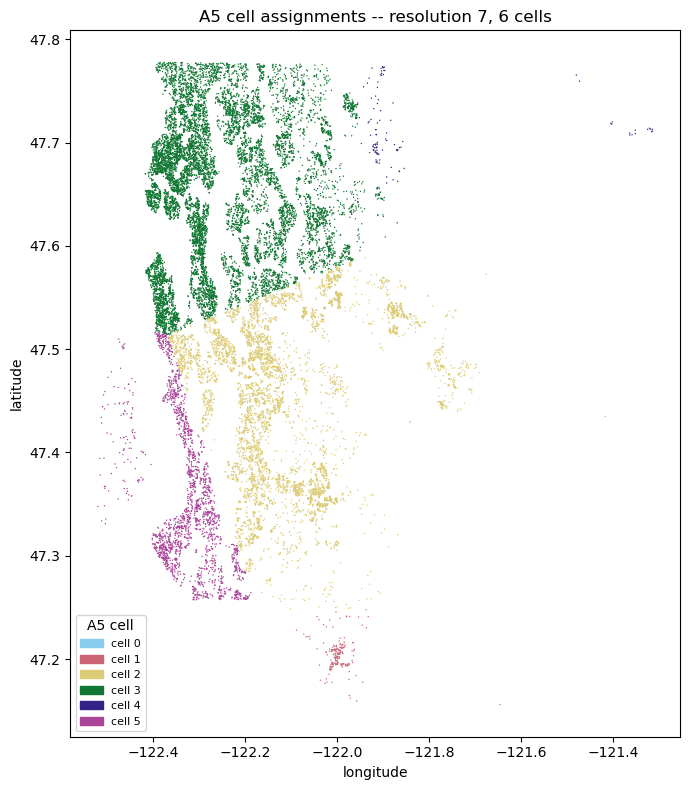

In [8]:
fig, ax = plt.subplots(figsize=(7, 8))
unique_cells, cell_int = np.unique(cv_a5.cell_ids_, return_inverse=True)
sc = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=cell_int, cmap=colormaps.safe[:len(unique_cells)], s=1, linewidths=0,
)
handles = [
    mpatches.Patch(color=sc.cmap(sc.norm(i)), label='cell ' + str(i))
    for i in range(len(unique_cells))
]
ax.legend(handles=handles, loc='lower left', fontsize=8, title='A5 cell')
ax.set_title('A5 cell assignments -- resolution ' + str(cv_a5.resolution_) + ', ' + str(cv_a5.n_cells_) + ' cells')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
plt.show()

### All folds

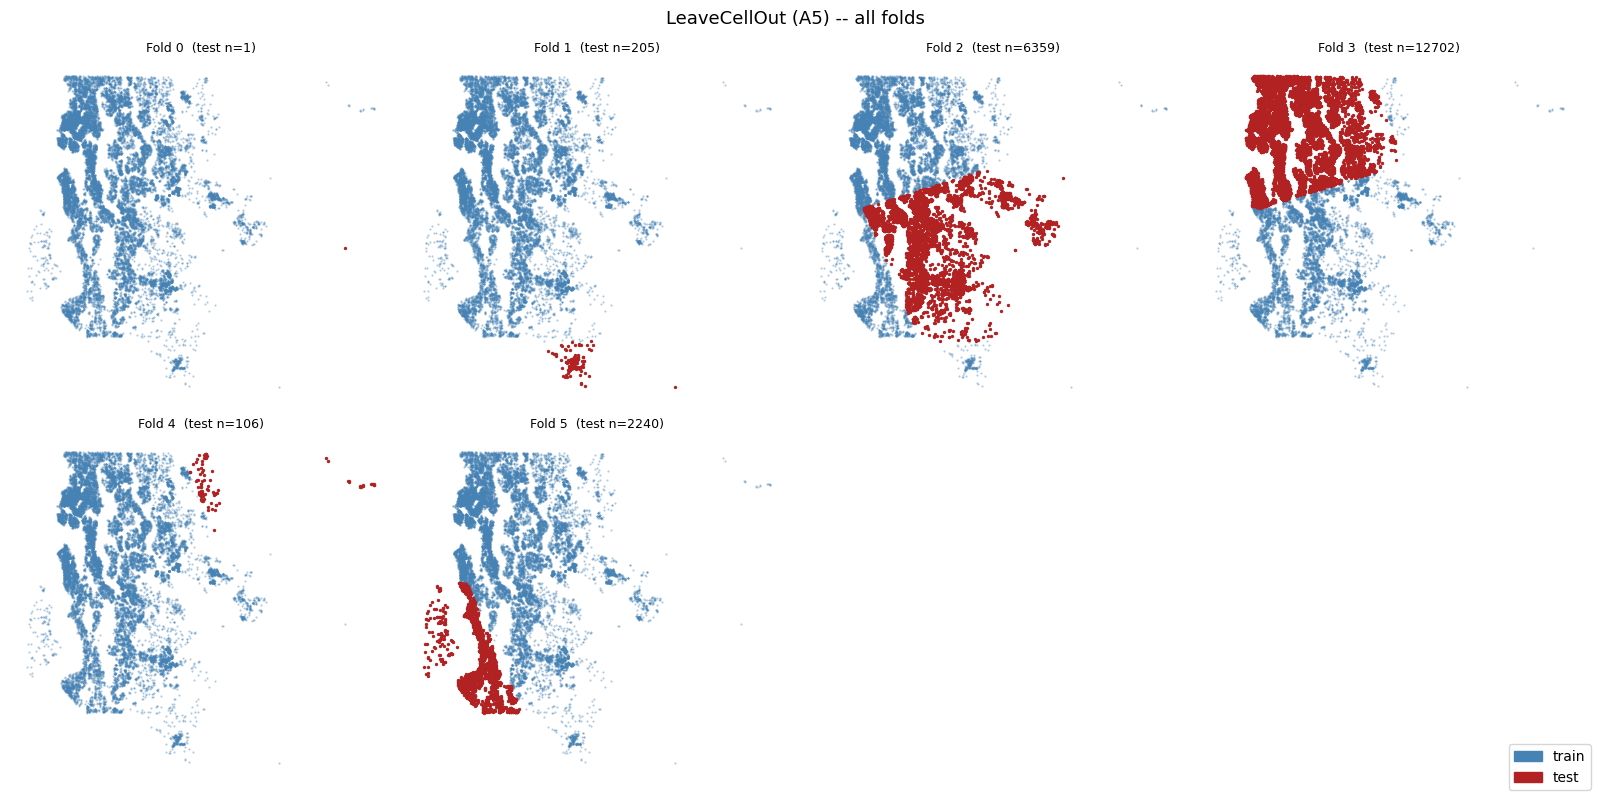

In [9]:
ncols = 4
nrows = int(np.ceil(cv_a5.n_cells_ / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flat

for i, (train, test) in enumerate(splits_a5):
    ax = axes[i]
    ax.scatter(
        gdf.geometry.x.iloc[train], gdf.geometry.y.iloc[train],
        color='steelblue', s=0.3, alpha=0.4,
    )
    ax.scatter(
        gdf.geometry.x.iloc[test], gdf.geometry.y.iloc[test],
        color='firebrick', s=2,
    )
    ax.set_title('Fold ' + str(i) + '  (test n=' + str(len(test)) + ')', fontsize=9)
    ax.set_axis_off()

for ax in list(axes)[cv_a5.n_cells_:]:
    ax.set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color='steelblue', label='train'),
        mpatches.Patch(color='firebrick', label='test'),
    ],
    loc='lower right', fontsize=10,
)
fig.suptitle('LeaveCellOut (A5) -- all folds', fontsize=13)
plt.tight_layout()
plt.show()

## HEALPix grid

HEALPix (Hierarchical Equal Area isoLatitude Pixelization) divides the sphere
into equal-area pixels arranged in rings of constant latitude. The `resolution`
parameter is log₂(nside), so resolution 7 = nside 128.
At this resolution, 7 cells cover King County — matching H3 resolution 4.

In [10]:
cv_hp = LeaveCellOut(grid='healpix', resolution=7)
splits_hp = list(cv_hp.split(gdf))
print('Resolution :', cv_hp.resolution_, f'(nside={1 << cv_hp.resolution_})')
print('Test folds :', cv_hp.n_cells_, '(one per occupied cell)')

Resolution : 7 (nside=128)
Test folds : 7 (one per occupied cell)


### Cell assignments

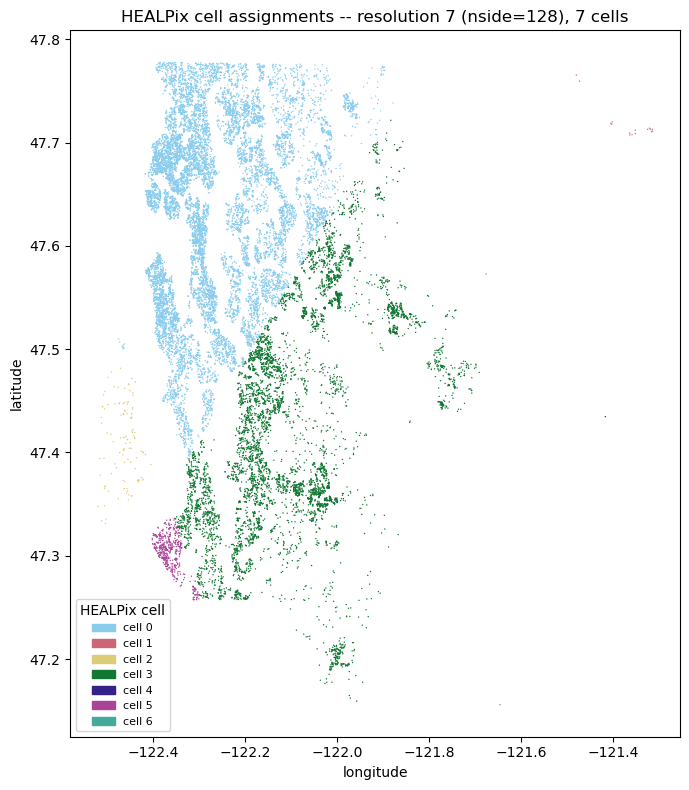

In [11]:
fig, ax = plt.subplots(figsize=(7, 8))
unique_cells, cell_int = np.unique(cv_hp.cell_ids_, return_inverse=True)
sc = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=cell_int, cmap=colormaps.safe[:len(unique_cells)], s=1, linewidths=0,
)
handles = [
    mpatches.Patch(color=sc.cmap(sc.norm(i)), label='cell ' + str(i))
    for i in range(len(unique_cells))
]
ax.legend(handles=handles, loc='lower left', fontsize=8, title='HEALPix cell')
ax.set_title('HEALPix cell assignments -- resolution ' + str(cv_hp.resolution_) + f' (nside={1 << cv_hp.resolution_}), ' + str(cv_hp.n_cells_) + ' cells')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
plt.show()

### All folds

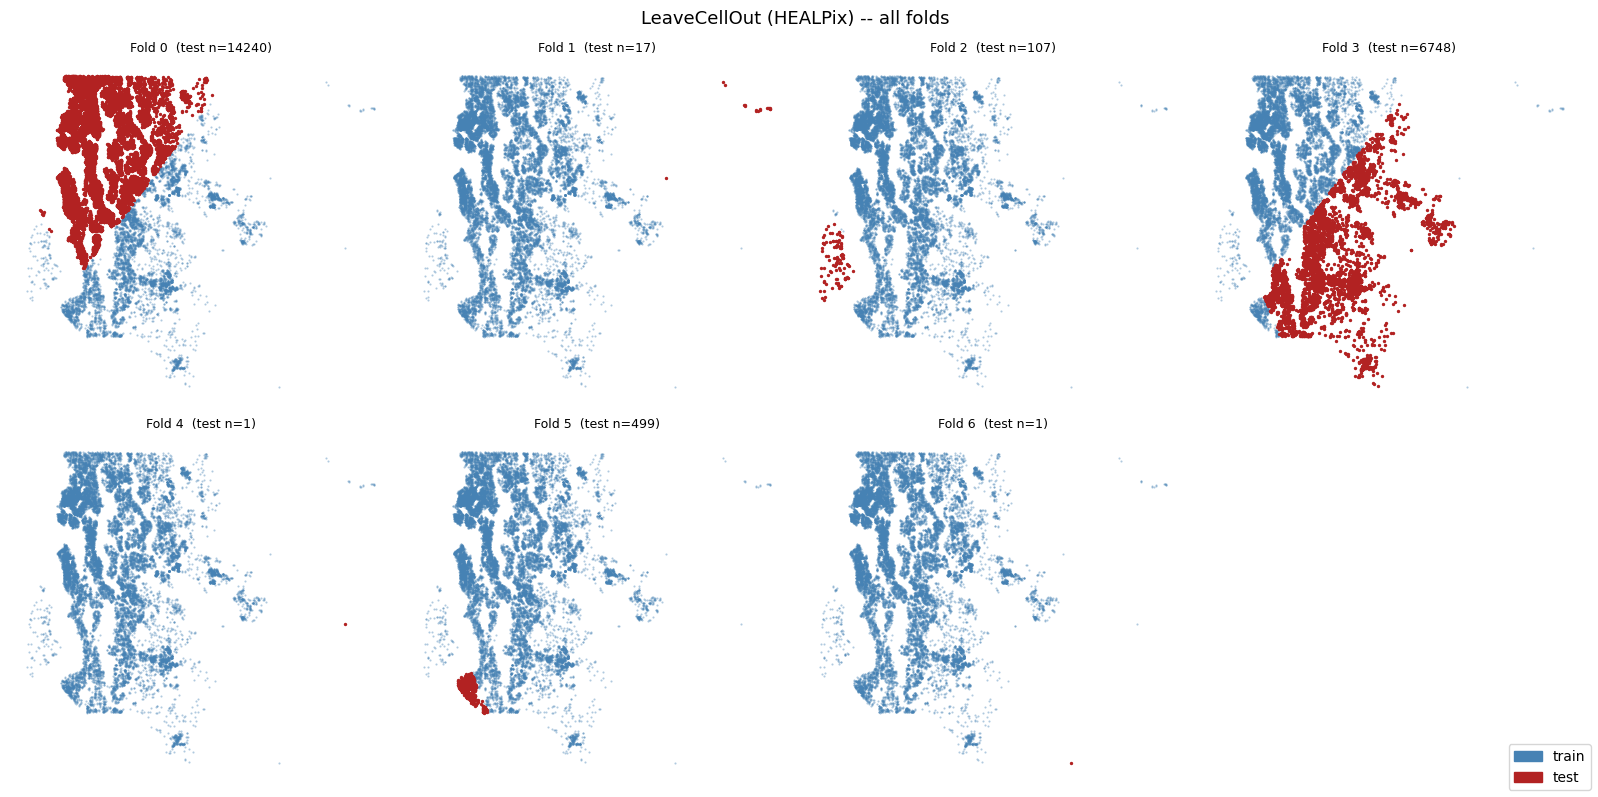

In [12]:
ncols = 4
nrows = int(np.ceil(cv_hp.n_cells_ / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flat

for i, (train, test) in enumerate(splits_hp):
    ax = axes[i]
    ax.scatter(
        gdf.geometry.x.iloc[train], gdf.geometry.y.iloc[train],
        color='steelblue', s=0.3, alpha=0.4,
    )
    ax.scatter(
        gdf.geometry.x.iloc[test], gdf.geometry.y.iloc[test],
        color='firebrick', s=2,
    )
    ax.set_title('Fold ' + str(i) + '  (test n=' + str(len(test)) + ')', fontsize=9)
    ax.set_axis_off()

for ax in list(axes)[cv_hp.n_cells_:]:
    ax.set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color='steelblue', label='train'),
        mpatches.Patch(color='firebrick', label='test'),
    ],
    loc='lower right', fontsize=10,
)
fig.suptitle('LeaveCellOut (HEALPix) -- all folds', fontsize=13)
plt.tight_layout()
plt.show()